# YOLOv1 — Colab Training & Evaluation
**Redmon et al., "You Only Look Once: Unified, Real-Time Object Detection" (CVPR 2016)**

Runtime → Change runtime type → **T4 GPU** 권장

In [1]:
# ── 1. GPU 확인 ────────────────────────────────────────────────────────────────
import torch
print('PyTorch :', torch.__version__)
print('CUDA    :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU     :', torch.cuda.get_device_name(0))

PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4


In [2]:
# ── 2. 코드 가져오기 (GitHub clone 방식 권장) ──────────────────────────────────
import os, sys

# ❶ 본인 GitHub 주소로 수정하세요
REPO_URL    = 'https://github.com/Gaeul5/YOLO_practice'
PROJECT_DIR = '/content/YOLO_practice'

if not os.path.isdir(PROJECT_DIR):
    os.system(f'git clone {REPO_URL} {PROJECT_DIR}')
    print('Clone 완료')
else:
    # 코드를 수정했으면 pull로 최신 상태 유지
    os.system(f'git -C {PROJECT_DIR} pull')
    print('Pull 완료')

os.chdir(PROJECT_DIR)
sys.path.insert(0, PROJECT_DIR)
print('Working dir:', os.getcwd())
print('Files      :', [f for f in os.listdir() if f.endswith('.py')])

Pull 완료
Working dir: /content/YOLO_practice
Files      : ['train.py', 'test.py', 'util.py', 'data.py', 'model.py']


In [3]:
# ── 3. (선택) Google Drive 마운트 — 체크포인트를 Drive에 저장하고 싶을 때 ────
# Drive에 저장하면 Colab 세션이 끊겨도 이어서 학습 가능

USE_DRIVE = False   # Drive 사용하려면 True 로 바꾸고 실행

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    CKPT_DIR = '/content/drive/MyDrive/YOLO_practice/checkpoints'
else:
    CKPT_DIR = os.path.join(PROJECT_DIR, 'checkpoints')

os.makedirs(CKPT_DIR, exist_ok=True)
print('Checkpoint dir:', CKPT_DIR)

Checkpoint dir: /content/YOLO_practice/checkpoints


In [4]:
# ── 4. Imports ─────────────────────────────────────────────────────────────────
import os, sys, random, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset

from model import YOLOv1
from data  import VOCDataset, IMG_SIZE
from train import YOLOLoss, train_one_epoch, build_lr_scheduler
from test  import compute_map, visualize
from util  import VOC_CLASSES, decode_predictions

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

Device: cuda


In [ ]:
# ── 5. Hyperparameters ─────────────────────────────────────────────────────────
S, B, C = 7, 2, 20

CFG = dict(
    data_root    = os.path.join(PROJECT_DIR, 'data'),
    epochs       = 10,       # 빠른 테스트용 (논문 기준 135)
    batch_size   = 16,       # GPU VRAM이 부족하면 8로 줄이세요
    lr           = 1e-2,
    weight_decay = 5e-4,
    num_workers  = 2,        # Colab 에서는 2 권장
    save_dir     = CKPT_DIR, # 셀 3에서 결정된 경로 사용
)
print(CFG)

{'data_root': '/content/YOLO_practice/data', 'epochs': 10, 'batch_size': 16, 'lr': 0.01, 'weight_decay': 0.0005, 'num_workers': 2, 'save_dir': '/content/YOLO_practice/checkpoints'}


In [6]:
# ── 6. Dataset ─────────────────────────────────────────────────────────────────
# 첫 실행 시 VOC 2007 + 2012 자동 다운로드 (~2GB)
train_set = ConcatDataset([
    VOCDataset(CFG['data_root'], year='2007', image_set='trainval', augment=True),
    VOCDataset(CFG['data_root'], year='2012', image_set='trainval', augment=True),
])
val_set = VOCDataset(CFG['data_root'], year='2007', image_set='test', augment=False)

train_loader = DataLoader(
    train_set, batch_size=CFG['batch_size'],
    shuffle=True, num_workers=CFG['num_workers'], pin_memory=True,
)
val_loader = DataLoader(
    val_set, batch_size=CFG['batch_size'],
    shuffle=False, num_workers=CFG['num_workers'],
)
print(f'Train: {len(train_set)}  |  Val: {len(val_set)}')

Train: 16551  |  Val: 4952


In [7]:
# ── 7. Model & Optimizer ───────────────────────────────────────────────────────
model     = YOLOv1(S=S, B=B, C=C).to(DEVICE)
criterion = YOLOLoss(S=S, B=B, C=C)
optimizer = optim.SGD(
    model.parameters(),
    lr=CFG['lr'], momentum=0.9, weight_decay=CFG['weight_decay'],
)
scheduler = build_lr_scheduler(optimizer)

total_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {total_params:,}')

Parameters: 271,716,734


In [ ]:
# ── 8. (선택) 체크포인트에서 이어서 학습 ──────────────────────────────────────
RESUME = None  # e.g. './checkpoints/yolov1_epoch050.pth'

start_epoch = 1
if RESUME and os.path.isfile(RESUME):
    ckpt = torch.load(RESUME, map_location=DEVICE)
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    start_epoch = ckpt['epoch'] + 1
    print(f'Resumed from epoch {ckpt["epoch"]}')

In [9]:
# ── 9. Training Loop ───────────────────────────────────────────────────────────
history = {'loss': [], 'lr': []}

for epoch in range(start_epoch, CFG['epochs'] + 1):
    t0   = time.time()
    loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    scheduler.step()
    lr_now = scheduler.get_last_lr()[0]

    history['loss'].append(loss)
    history['lr'].append(lr_now)
    elapsed = time.time() - t0
    print(f'[{epoch:03d}/{CFG["epochs"]}]  loss={loss:.4f}  '
          f'lr={lr_now:.2e}  ({elapsed:.0f}s)')

    if epoch % 10 == 0 or epoch == CFG['epochs']:
        path = os.path.join(CFG['save_dir'], f'yolov1_epoch{epoch:03d}.pth')
        torch.save({'epoch': epoch, 'model': model.state_dict(),
                    'optimizer': optimizer.state_dict(), 'loss': loss}, path)
        print(f'  → Saved {path}')

print('Training complete.')

[001/10]  loss=8.1026  lr=1.00e-02  (443s)
[002/10]  loss=7.9639  lr=1.00e-02  (441s)
[003/10]  loss=7.0987  lr=1.00e-02  (441s)
[004/10]  loss=7.0843  lr=1.00e-02  (441s)
[005/10]  loss=6.9803  lr=1.00e-02  (441s)
[006/10]  loss=6.8866  lr=1.00e-02  (441s)
[007/10]  loss=6.8037  lr=1.00e-02  (441s)
[008/10]  loss=6.6954  lr=1.00e-02  (441s)
[009/10]  loss=6.7348  lr=1.00e-02  (441s)
[010/10]  loss=6.6081  lr=1.00e-02  (440s)
  → Saved /content/YOLO_practice/checkpoints/yolov1_epoch010.pth
Training complete.


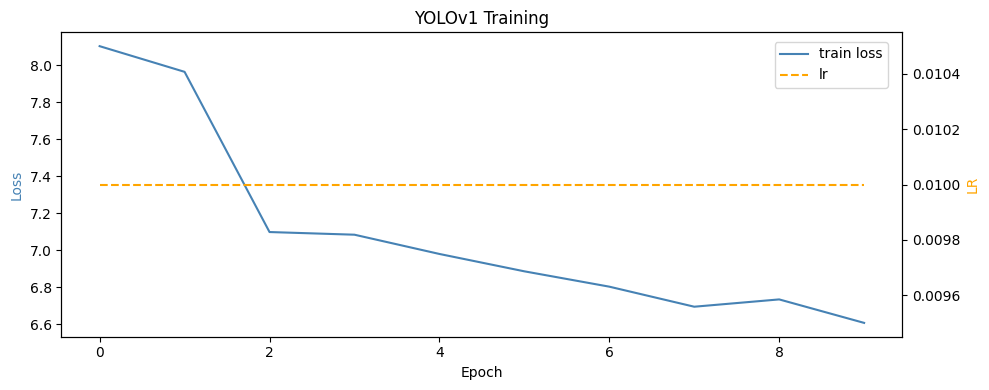

In [10]:
# ── 10. Loss curve ─────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(history['loss'], label='train loss', color='steelblue')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss', color='steelblue')
ax2 = ax1.twinx()
ax2.plot(history['lr'], label='lr', color='orange', linestyle='--')
ax2.set_ylabel('LR', color='orange')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.title('YOLOv1 Training')
plt.tight_layout()
plt.show()

In [11]:
# ── 11. Evaluation — mAP@0.5 ──────────────────────────────────────────────────
mAP = compute_map(model, val_loader, DEVICE, iou_thresh=0.5, conf_thresh=0.25)
print(f'Final mAP@0.5: {mAP:.4f}')


Class            AP
--------------------------
aeroplane        0.000
bicycle          0.000
bird             0.000
boat             0.000
bottle           0.000
bus              0.000
car              0.000
cat              0.000
chair            0.000
cow              0.000
diningtable      0.000
dog              0.000
horse            0.000
motorbike        0.000
person           0.000
pottedplant      0.000
sheep            0.000
sofa             0.000
train            0.000
tvmonitor        0.000
--------------------------
mAP@0.5          0.0000

Final mAP@0.5: 0.0000


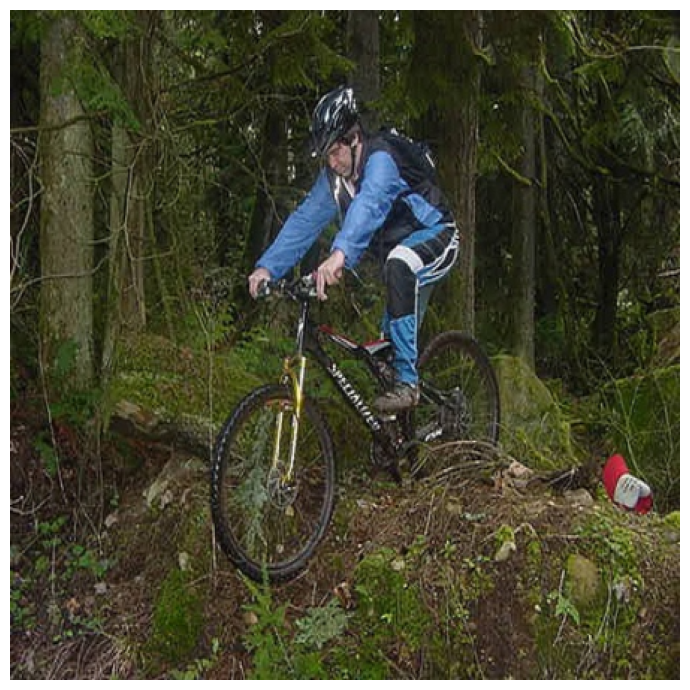

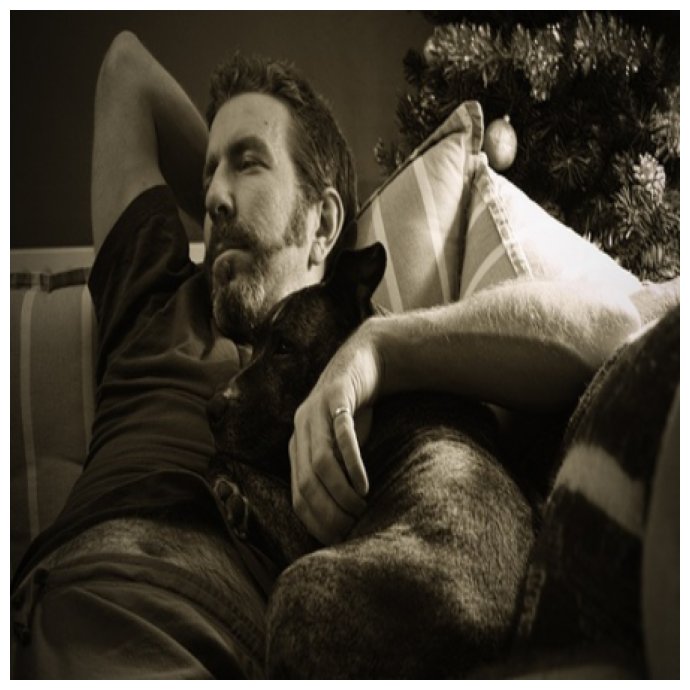

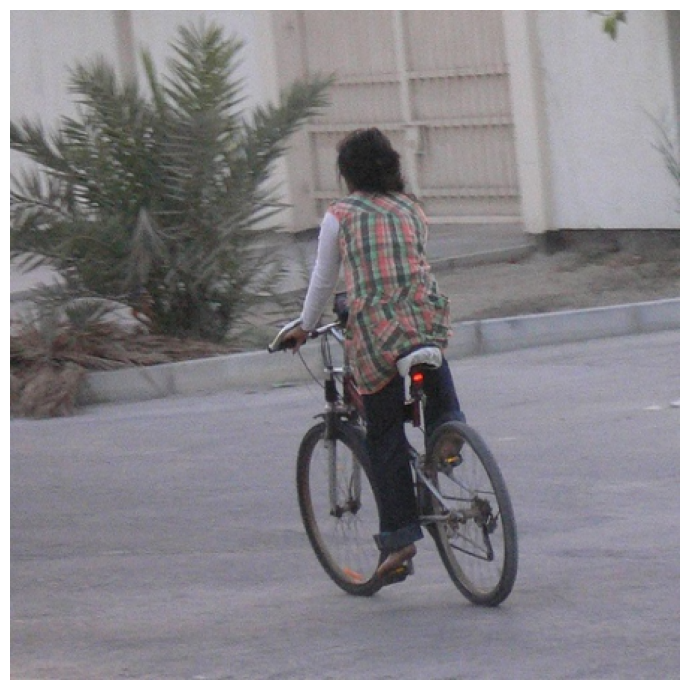

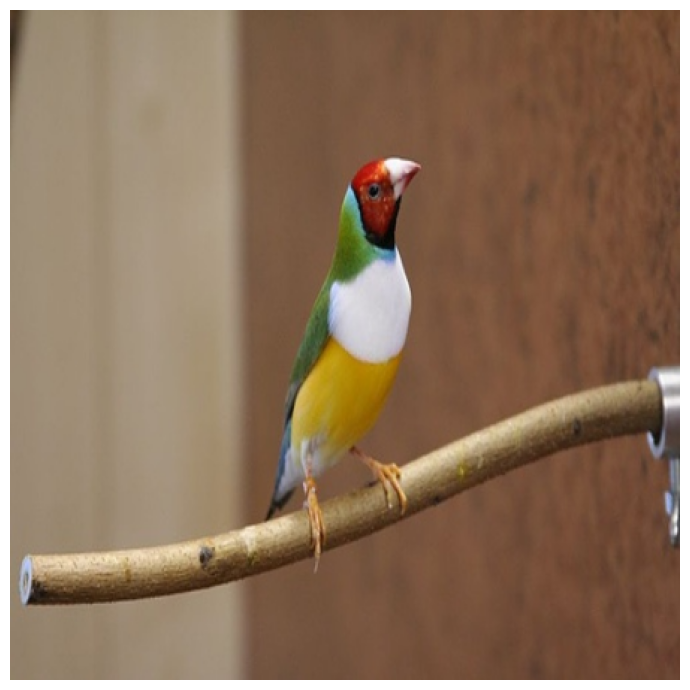

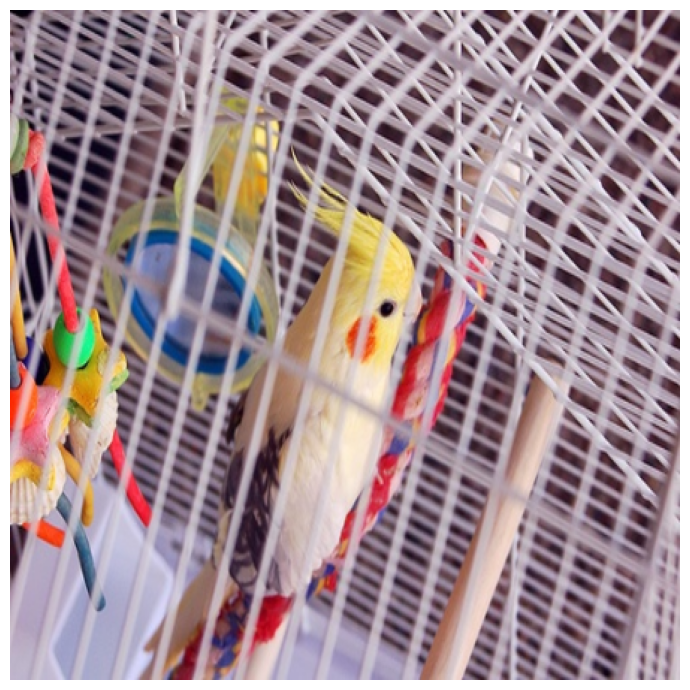

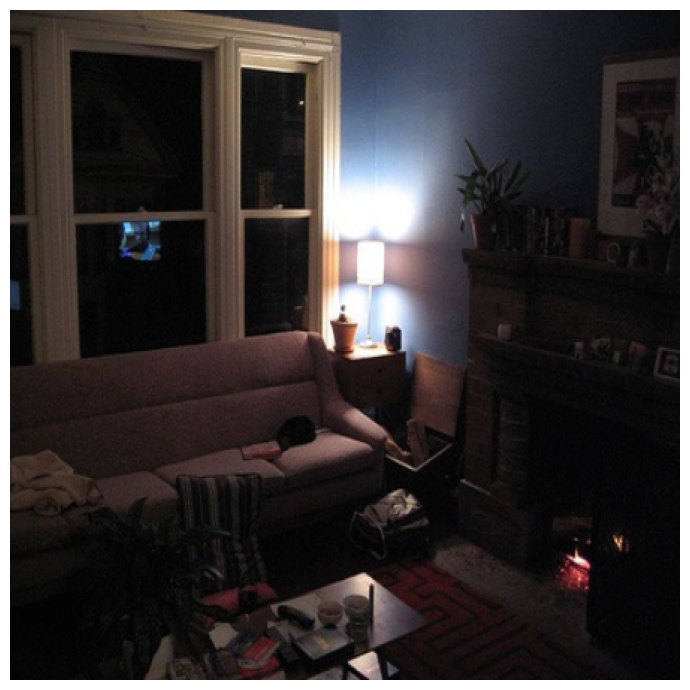

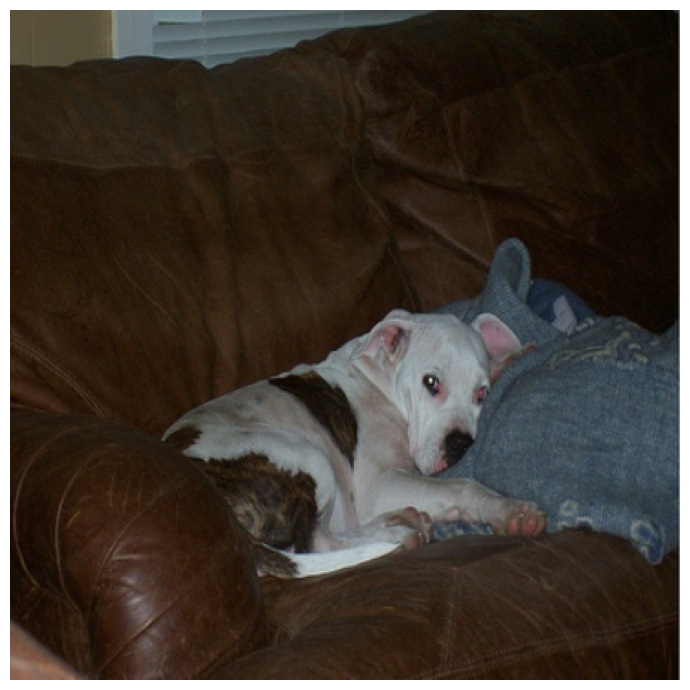

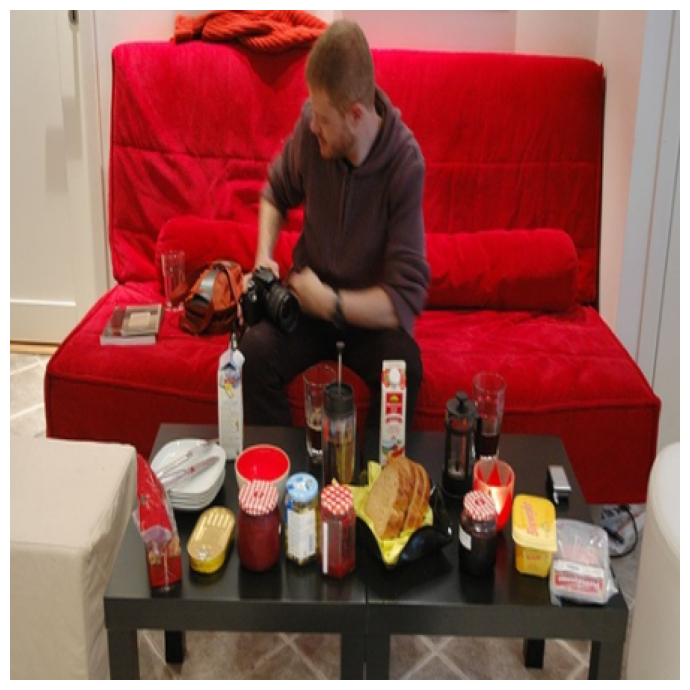

In [12]:
# ── 12. Qualitative visualization ─────────────────────────────────────────────
visualize(
    model, val_set, DEVICE,
    n=8, conf_thresh=0.25,
    save_dir='./vis',
)